In [42]:
import pandas as pd
import networkx as nx

In [43]:
painters = pd.read_csv('PainterPalette.csv')

In [44]:
painters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10361 entries, 0 to 10360
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   artist                     10361 non-null  object 
 1   Nationality                2428 non-null   object 
 2   citizenship                8931 non-null   object 
 3   gender                     9979 non-null   object 
 4   styles                     3202 non-null   object 
 5   movement                   3202 non-null   object 
 6   Art500k_Movements          3872 non-null   object 
 7   birth_place                8652 non-null   object 
 8   death_place                6930 non-null   object 
 9   birth_year                 9456 non-null   float64
 10  death_year                 7729 non-null   float64
 11  FirstYear                  7200 non-null   float64
 12  LastYear                   7200 non-null   float64
 13  wikiart_pictures_count     3202 non-null   flo

In [45]:
painters.isnull().sum()

,0
artist,0
Nationality,7933
citizenship,1430
gender,382
styles,7159
movement,7159
Art500k_Movements,6489
birth_place,1709
death_place,3431
birth_year,905


In [46]:
painters_subset_of_cols = painters[["artist", "Influencedby", "Influencedon", "Pupils", "Teachers", "FriendsandCoworkers"]]

In [47]:
painters_subset_of_cols.head()

,artist,Influencedby,Influencedon,Pupils,Teachers,FriendsandCoworkers
0,Bracha L. Ettinger,NaN,NaN,NaN,NaN,NaN
1,William H. Johnson,NaN,NaN,NaN,NaN,NaN
2,Alexey Bogolyubov,NaN,NaN,NaN,NaN,NaN
3,O. Louis Guglielmi,NaN,NaN,NaN,NaN,NaN
4,Mikalojus Konstantinas Ciurlionis,"allegories-and-symbols,boats-and-ships,",NaN,"The cycle of 5 paintings Deluge,",NaN,"Artists2/Mikalojus Ciurlionis/Wrath Ii 1904.jpg,"


In [48]:
painters_subset_of_cols.dropna().head()

,artist,Influencedby,Influencedon,Pupils,Teachers,FriendsandCoworkers
236,Fernand Leger,"Henri Rousseau,Paul Cezanne,Henri Matisse,","Roy Lichtenstein,James Rosenquist,Ellsworth Ke...","Nadir Afonso,Asger Jorn,Tarsila do Amaral,Loui...","Jean-Leon Gerome,Académie Julian, Paris, Franc...","Marc Chagall,Piet Mondrian,Le Corbusier,Robert..."
246,Giacomo Balla,"Mario Sironi,posters-and-advertisements,logoty...","Futuro,Transformación forma-espíritu,Compenetr...","Mario Sironi,","Artists2/Giacomo Balla/Future 1923.jpg,Artists...",Artists2/Giacomo Balla/Poster For Casa D Arte ...
798,Józef Mehoffer,Polichromia Kościoła Najświętszego Serca Pana ...,"Jan Matejko Academy of Fine Arts, Krakow, Pola...","Jan Matejko Academy of Fine Arts, Krakow, Pola...","Jan Matejko,","Stanisław Wyspiański,Jan Matejko,"
800,Kazimir Malevich,"Aristarkh Lentulov,","Josef Albers,Ad Reinhardt,Nasreen Mohamedi,","El Lissitzky,","Mykola Pymonenko,Vitebsk Art School, Vitebsk, ...","Olga Rozanova,Lyubov Popova,Aleksandra Ekster,..."
876,Carel Fabritius,"Rembrandt,","Delft School,Johannes Vermeer,Pieter de Hooch,","Johannes Vermeer,","Rembrandt,","Samuel Dirksz van Hoogstraten,"


In [49]:
# create a network where the nodes are all the artists
G = nx.DiGraph()
G.add_nodes_from(painters["artist"].dropna().unique())

In [50]:
# count nodes
G.number_of_nodes()

10361

In [51]:
for _, row in painters.iterrows():
  if row["Influencedby"] is not None:
    influences = str(row["Influencedby"]).split(",")
    for influence in influences:
      if influence in G:
        G.add_edge(influence, row["artist"], edge_type="influence")

In [52]:
# count edges
G.number_of_edges()

724

In [53]:
for _, row in painters.iterrows():
  if row["Influencedon"] is not None:
    influencees = str(row["Influencedon"]).split(",")
    for influencee in influencees:
      if influencee in G and not G.has_edge(row["artist"], influencee):
        G.add_edge(row["artist"], influencee, edge_type="influence")

print(G.number_of_edges())

852


In [54]:
for _, row in painters.iterrows():
  if row["Pupils"] is not None:
    pupils = str(row["Pupils"]).split(",")
    for pupil in pupils:
      if pupil in G:
        G.add_edge(row["artist"], pupil, edge_type="taught")

print(G.number_of_edges())

1037


In [55]:
for _, row in painters.iterrows():
  if row["Teachers"] is not None:
    teachers = str(row["Teachers"]).split(",")
    for teacher in teachers:
      if teacher in G and not G.has_edge(teacher, row["artist"]):
        G.add_edge(teacher, row["artist"], edge_type="taught")

print(G.number_of_edges())

1055


In [56]:
for _, row in painters.iterrows():
  if row["FriendsandCoworkers"] is not None:
    friends = str(row["FriendsandCoworkers"]).split(",")
    for friend in friends:
      if friend in G:
        G.add_edge(row["artist"], friend, edge_type="friend_coworker")
        G.add_edge(friend, row["artist"], edge_type="friend_coworker")

print(G.number_of_edges())

1651


In [59]:
# drop nodes that don't have any edges
for node in list(G.nodes()):
  if G.degree(node) == 0:
    G.remove_node(node)

print(G.number_of_nodes())
print(G.number_of_edges())

652
1651


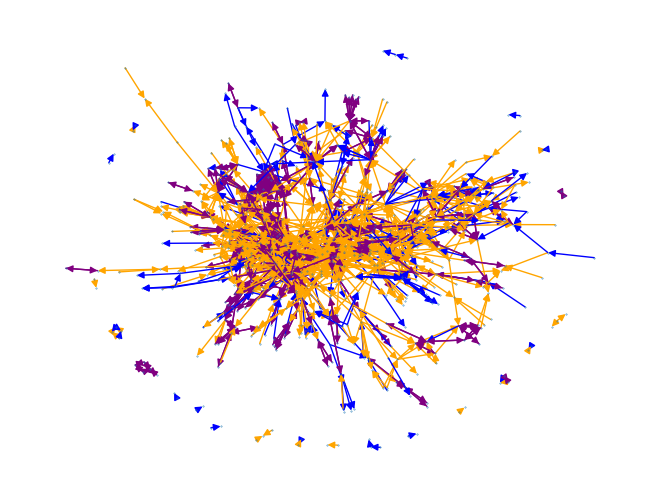

In [61]:
import matplotlib.pyplot as plt

# define color mapping
color_map = {
    "influence": "orange",
    "taught": "blue",
    "friend_coworker": "purple"
}

# extract edge colors
edge_colors = [
    color_map[G[u][v]["edge_type"]]
    for u, v in G.edges()
]

nx.draw(G, node_size=0.1, edge_color=edge_colors)
plt.show()